In [3]:
import pandas as pd

# 1. 가상 데이터 생성 (접수 대장 양식 예시)
# 🟢행, 열에 대한 설명 (출력 후 엑셀 확인!)
public_data = {
    '접수번호': ['2024-001', '2024-002', '2024-003', '2024-004', '2024-005'],
    '접수일자': ['2024-03-01', '2024-03-02', '2024-03-02', '2024-03-03', '2024-03-04'],
    '업무부서': ['교통', '환경', '도로', '환경', '교통'],
    '처리상태': ['완료', '처리중', '완료', '반려', '처리중'],
    '진행건수': [5, 3, 4, 2, 4]
}

df_public = pd.DataFrame(public_data)

# 2. CSV 파일로 🍋저장 (공공기관에서 가장 많이 쓰는 형식)
# encoding='cp949': 엑셀 한글 파일명이 깨지지 않고 잘 열림.
df_public.to_csv('업무_유형별통계.csv', index=False, encoding='cp949')

print("업무_유형별통계 CSV 파일 생성 완료!")

업무_유형별통계 CSV 파일 생성 완료!


Text(0, 0.5, '진행 건수')

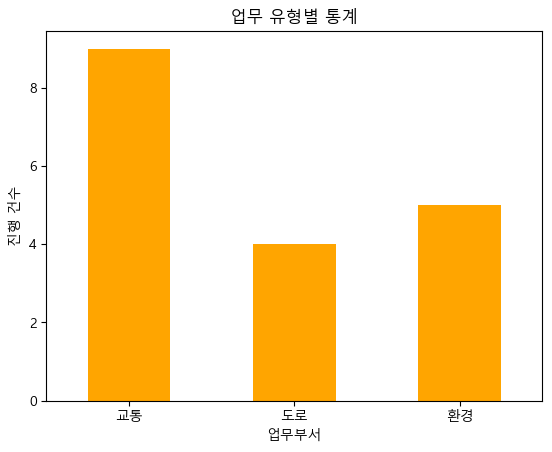

In [4]:
import matplotlib.pyplot as plt
# 🔴🟢엑셀 파일의 [열 제목] 확인
# 1. CSV 파일 불러오기 🍋불러올 때도 인코딩(한글 파일명)
df = pd.read_csv('업무_유형별통계.csv', encoding='cp949')

# 2-1 민원유형별 개수 세기 
# type_counts = df['업무부서'].value_counts() #행 개수
# 2-2💡'진행건수' 열을 숫자형으로 변환 (에러 방지용)
# 🟢errors='coerce' 알 수 없는 형식, 오류는 에러를 내지 말고 NaN(결측치)으로 처리해라
df['진행건수'] = pd.to_numeric(df['진행건수'], errors='coerce')
# 2-3💡부서별로 '진행건수'의 합계를 구하기 (value_counts 대신 사용)
# 🟢'업무부서'로 묶고, '진행건수' 열만 선택해서 더합니다.
type_sums = df.groupby('업무부서')['진행건수'].sum()

# 3. 그래프 그리기
plt.rcParams['font.family'] = 'Malgun Gothic' 
# type_counts.plot(kind='bar', rot=0, color='red') # 1️⃣행 개수, 색상
type_sums.plot(kind='bar', rot=0, color='orange') # 2️⃣진행 건수
plt.title('업무 유형별 통계')
#plt.xlabel('민원 유형') #생략 가능
plt.ylabel('진행 건수') # 3️⃣rotation=0, labelpad=30, va='center' 추가해보기
#plt.show() #주피터 노트북 한정 생략 가능